# What do the SARS-Cov-2 genes do?


One process in the analysis of a new organism is annotating the genome. The first step of this analysis is to find potential genes through identifying open reading frames (ORFs). 
After this, the next question is which of these correspond to actual genes?

To answer this, we will lean on what we know about evolution. If two species are morphologically different, their genetic material must also differ substantially. Right? Not exactly. Evolution conserved many genes crucial for survival. The degree of conservation is surprising. For example, while we would expect to share many genes with the chimpanzee, our closest relative, we would expect almost no similarity in our genetic material with bananas. The numbers tell us otherwise. While sharing 96% of our genes with the chimpanzee, we also share 60% of our genes with bananas! These similar genes in humans and bananas encode proteins that carry similar functions.

Two genes with similar sequences may perform similar functions. Genes like these are called homologous genes. Or, more precisely, in our case, these would be orthologous genes (see the figure below). A pair of orthologous genes are genes from two related species originating from a common ancestor (e.g., humans and chimpanzees). Due to the evolution, the two nucleotide or protein sequences might differ slightly but not overwhelmingly.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d8/Ortholog_paralog_analog_%28homologs%29.svg/1200px-Ortholog_paralog_analog_%28homologs%29.svg.png" width="500">
</div>

*Author: Thomas Shafee, Licence: CC BY 4.0*

The human-banana example demonstrates that these two organisms don't have to be that closely related! If we tried to determine the gene function in humans using bananas as a reference, we could infer the role of over 60% of the genes. However, using two closely related organisms would undoubtedly give us more robust results. We would be better off choosing the genome of a mouse or a chimpanzee as our reference.

Scientists have studied hundreds of viruses and determined the functions of most of their genes. Using viruses similar in sequence to SARS-Cov-2, we can characterize the SARS-CoV-2 ORFs to determine if they are the actual genes, and think about their function. Knowing what each gene does might help us find a way to fight the infection and potentially even find treatments for COVID-19. 

#### Please ensure each answer is completed in the single cell of the notebook immediately following the question, and that all answers are in ```markdown``` format.

Once you have completed the notebook, make sure you save it and submit it via Moodle.

All questions are worth between 4 and 10 marks. There are a total of *40 marks* available in this workbook. There is an extra bonus problem for *10 marks*. 
  
Total notebook marks will be scaled to a **course mark out of 10** to contribute to your course total.

In [1]:
import numpy as np
from Bio import Entrez

In [2]:
# In order to import from the python file without hassle, we add the current
# directory to the python path
import sys; sys.path.append(".")

Let's let the nice folks at NCBI know who we are.

In [ ]:
Entrez.email = "xingjian.dong@student.unsw.edu.au"

## Finding SARS-CoV-2's closest relatives

In the first part of this assignment, we will analyze several coronavirus genomes to determine which are most similar to SARS-CoV-2. We will then use the viruses with the most similar sequence as reference genomes to assign functions to SARS-CoV-2 ORFs.

To find the closest reference genomes, we will align the SARS-CoV-2 sequence to each candidate coronavirus genome. The virus genomes with the highest alignment scores will be our most closely-related viruses.

Notice that computing an alignment between two sequences of length $N$ and $M$ requires the computation of a dynamic programming table with $N \cdot M$ entries. The size of this matrix is sufficiently small for short sequences. But even the short genomes, like viral genomes, are generally too long for this approach. Instead of computing similarities from the entire genomes, we will only focus on the spike protein sequence. In general, we would prefer to align the whole nucleotide sequences, but for this assignment, considering only a spike protein will be sufficient. The spike protein is also one of the essential parts of any coronavirus, as it is the one that grants the virus entry to host cells. 

Considering spike proteins alone reduces the sequence lengths from ~30k (entire virus) to around 1.3k (spike protein). Nevertheless, do your best to write fast, efficient Python code. Each `global_alignment` call on 1.3k long protein sequences should take around 30 to 60 seconds. 
We have to calculate 20 comparisons, which takes roughly 10 to 20 minutes.

In [4]:
accession_codes = {
    # 6 known human coronaviruses
    "Human-SARS": "NC_004718",
    "Human-MERS": "NC_019843",
    "Human-HCoV-OC43": "NC_006213",
    "Human-HCoV-229E": "NC_002645",
    "Human-HCoV-NL63": "NC_005831",
    "Human-HCoV-HKU1": "NC_006577",
    
    # Bat
    "Bat-CoV MOP1": "EU420138",
    "Bat-CoV HKU8": "NC_010438",
    "Bat-CoV HKU2": "NC_009988",
    "Bat-CoV HKU5": "NC_009020",
    "Bat-CoV RaTG13": "MN996532",
    "Bat-CoV-ENT": "NC_003045",
    
    # Other animals
    "Hedgehog-CoV 2012-174/GER/2012": "NC_039207",
    "Pangolin-CoV MP789": "MT121216",
    "Rabbit-CoV HKU14": "NC_017083",
    "Duck-CoV isolate DK/GD/27/2014": "NC_048214",
    "Feline infectious peritonitis virus": "NC_002306",  # cat
    "Giraffe-CoV US/OH3/2003": "EF424623",
    "Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012": "KF268338",  # mouse
    "Equine-CoV Obihiro12-2": "LC061274",  # horse
}

Above is the list of coronaviruses and their corresponding NCBI accession codes that we will consider in this assignment. You can find the SARS-CoV-2 sequence in `data/sars_cov_2.fa`. This time, we will use the FASTA format to familiarize ourselves with the sequence file formats used in bioinformatics. You can easily read FASTA files using the `SeqIO.read` function from `biopython`.

We will only use part of the sequence, and to assess similarity, consider the spike protein alone. We will assume that we know the location of the spike protein in SARS-CoV-2 (strand=1, start=21562, stop=25384). We need to find a part of the sequence that encodes for the spike protein in all coronaviruses listed above. We can inspect each sequence's features to locate the spike protein. For this assignment, we will iterate through gene coding regions (CDS) for each coronavirus and find the one that codes for the "S" gene. Some coronaviruses do not include such annotation but instead report on a "spike protein" in the `product` field.

## Problem 1: Global alignment

**Task:** Use the template `global_alignment` function in the helper file to implement the Needleman-Wunsch algorithm for global sequence alignment. Use a "-" character for indels. Score the alignments using the BLOSUM62 substitution matrix. You can find it in `biopython`.

**[10 points]**

In [5]:
from helper_functions import global_alignment
result = global_alignment("abracadabra", "dabarakadara", lambda x, y: [-1, 1][x == y])
print(result)

('-ab-racadabra', 'dabarakada-ra', 5.0)


## Problem 2: Choosing our reference genomes

**Task:** Identify the three closest relatives to SARS-CoV-2. Use the `global_alignment` function you have just implemented, inspect their alignment scores, and select the three most similar sequences to our spike protein sequence. These will serve as reference genomes in Problem 4 of this assignment and help us determine the function of ORFs.

Save the full names of three coronaviruses with the closest matches to SARS-CoV-2's spike protein sequence as a Python list in the `three_closest_references` variable.

**[6 points]**

Then answer the following questions about global alignment and the three closest references.
- When aligning spike protein sequences with the global alignment, we used the BLOSUM62 substitution matrix by default. Examine the similarity of the protein alignments (the frequency of matching amino acids) and discuss whether it would be better to use the BLOSUM90 or BLOSUM45 substitution matrix in our case.
- The theory of evolution states that the SARS-CoV-2 virus must have evolved from some other virus in the past. Based on the three closest alignment references, is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus? (We will explore this further in the following exercise.)

Store your answers in the `blosum_selection` and `viral_origin` variables, respectively.

**[4 points]**.

In [31]:
from Bio.Seq import Seq
from Bio import SeqIO

sars_record = SeqIO.read("data/sars_cov_2.fa", "fasta")
sars_spike_cds = sars_record.seq[21562:25384]
sars_spike_protein = str(Seq(sars_spike_cds).translate()).replace("*", "")
print(f"SARS-CoV-2 spike protein length: {len(sars_spike_protein)}")

SARS-CoV-2 spike protein length: 1273


In [32]:
from Bio.Align import substitution_matrices

# Load BLOSUM62 substitution matrix
blosum62 = substitution_matrices.load("BLOSUM62")

def blosum62_scoring(aa1, aa2):
    try:
        return blosum62[aa1, aa2]
    except KeyError:
        return -4  # Handle unknown amino acids

In [33]:
from Bio import Entrez, SeqIO
from Bio.Seq import Seq
import time

Entrez.email = "xingjian.dong@student.unsw.edu.au"
virus_spike_proteins = {}
for name, accession in accession_codes.items():
    try:
        handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
        record = SeqIO.read(handle, "genbank")
        handle.close()

        spike_seq = None
        for feature in record.features:
            if feature.type == "CDS":
                gene = feature.qualifiers.get("gene", [""])[0]
                product = feature.qualifiers.get("product", [""])[0]
                if gene == "S" or "spike" in product.lower():
                    spike_seq = feature.extract(record.seq)
                    break

        if spike_seq:
            protein_seq = str(spike_seq.translate()).replace("*", "")
            virus_spike_proteins[name] = protein_seq
            print(f"Extracted spike protein for {name}, length: {len(protein_seq)}")
        else:
            print(f"Warning: No spike protein found for {name}")
    except Exception as e:
        print(f"Error downloading {name}: {e}")

Extracted spike protein for Human-SARS, length: 1255
Extracted spike protein for Human-MERS, length: 1353
Extracted spike protein for Human-HCoV-OC43, length: 1353
Extracted spike protein for Human-HCoV-229E, length: 1173
Extracted spike protein for Human-HCoV-NL63, length: 1356
Extracted spike protein for Human-HCoV-HKU1, length: 1356
Extracted spike protein for Bat-CoV MOP1, length: 1375
Extracted spike protein for Bat-CoV HKU8, length: 1375
Extracted spike protein for Bat-CoV HKU2, length: 1128
Extracted spike protein for Bat-CoV HKU5, length: 1352
Extracted spike protein for Bat-CoV RaTG13, length: 1269
Extracted spike protein for Bat-CoV-ENT, length: 1363
Extracted spike protein for Hedgehog-CoV 2012-174/GER/2012, length: 1330
Extracted spike protein for Pangolin-CoV MP789, length: 1265
Extracted spike protein for Rabbit-CoV HKU14, length: 1362
Extracted spike protein for Duck-CoV isolate DK/GD/27/2014, length: 1191
Extracted spike protein for Feline infectious peritonitis virus, 

In [34]:
scores = {}
for name, ref_protein in virus_spike_proteins.items():
    start_time = time.time()
    aligned1, aligned2, score = global_alignment(sars_spike_protein, ref_protein, blosum62_scoring)
    scores[name] = score
    print(f"Aligned {name} in {time.time() - start_time:.1f} seconds. Score: {score}")

sorted_viruses = sorted(scores.items(), key=lambda x: x[1], reverse=True)
three_closest_references = [name for name, score in sorted_viruses[:3]]
print("\nTop 3 closest relatives:", three_closest_references)

Aligned Human-SARS in 2.5 seconds. Score: 5409.0
Aligned Human-MERS in 2.7 seconds. Score: 2719.0
Aligned Human-HCoV-OC43 in 2.6 seconds. Score: 2694.0
Aligned Human-HCoV-229E in 2.3 seconds. Score: 2274.0
Aligned Human-HCoV-NL63 in 2.6 seconds. Score: 2388.0
Aligned Human-HCoV-HKU1 in 12.3 seconds. Score: 2624.0
Aligned Bat-CoV MOP1 in 13.9 seconds. Score: 2416.0
Aligned Bat-CoV HKU8 in 2.7 seconds. Score: 2403.0
Aligned Bat-CoV HKU2 in 5.3 seconds. Score: 2268.0
Aligned Bat-CoV HKU5 in 11.4 seconds. Score: 2778.0
Aligned Bat-CoV RaTG13 in 2.5 seconds. Score: 6555.0
Aligned Bat-CoV-ENT in 2.7 seconds. Score: 2708.0
Aligned Hedgehog-CoV 2012-174/GER/2012 in 5.8 seconds. Score: 2630.0
Aligned Pangolin-CoV MP789 in 2.5 seconds. Score: 6167.0
Aligned Rabbit-CoV HKU14 in 2.6 seconds. Score: 2702.0
Aligned Duck-CoV isolate DK/GD/27/2014 in 2.3 seconds. Score: 2373.0
Aligned Feline infectious peritonitis virus in 7.3 seconds. Score: 2524.0
Aligned Giraffe-CoV US/OH3/2003 in 2.7 seconds. Scor

In [35]:
three_closest_references = [  # Enter the three most closely-related viruses
    "Bat-CoV RaTG13",
    "Pangolin-CoV MP789",
    "Human-SARS",
]

In [36]:
blosum_selection = """
Would it be better to use BLOSUM90 or BLOSUM45 substitution matrix in our case?
Based on the high alignment scores, the spike protein sequences of the three reference viruses are highly similar to SARS-CoV-2.
Therefore, it would be better to use the BLOSUM90 substitution matrix in our case.
BLOSUM90 is designed for comparing closely related sequences (high similarity, e.g., >90% identity)
and applies a heavier penalty for mismatches, which is ideal for identifying subtle differences among highly similar viral sequences.
Conversely, BLOSUM45 is more suited for distant evolutionary relationships.
"""

In [37]:
viral_origin = """
Is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus?
Based on the three closest alignment references,
it is more likely that SARS-CoV-2 jumped from another host organism (zoonotic transmission)
rather than evolving from a human coronavirus. The top two closest relatives are Bat-CoV RaTG13 and Pangolin-CoV MP789,
which have higher alignment scores than the human coronavirus (Human-SARS).
This strongly suggests that SARS-CoV-2 originated in animal reservoirs (such as bats or pangolins) before spilling over to humans.
"""

## MiniBLAST

A sophisticated approach for characterizing any genetic sequence is BLAST. BLAST stores a database of annotated genes (usually from various organisms) and then uses local alignment and heuristic search to find database genes with a similar sequence to a query one. Assuming that genes with similar protein sequences perform similar functions, we can infer the function of a query sequence by looking at the function of any matching genes returned by BLAST. It is also possible that BLAST will not find suitable matches, which may signal that a sequence might not be an actual gene or protein. In this problem, we will implement our simplified BLAST version and call it MiniBLAST. We will use MiniBLAST to determine whether each of our candidate ORFs is a gene. And if it is a gene, we will use the annotations to determine what the gene does.

Please note that BLAST is a complicated, optimized, heuristic, state-of-the-art technique to obtain very good approximate solutions. BLAST can query thousands of sequences in seconds. Our implementation will be slightly less sophisticated and somewhat more constrained but conceptually similar to that of BLAST.

## Problem 3: Local alignment

**Task:** Use the template `local_alignment` in the helper file and implement the Smith-Waterman algorithm for local sequence alignment.

**[10 points]**

In [38]:
from helper_functions import local_alignment
print(local_alignment("pending itch", "unending glitch", lambda x, y: [-1, 1][x == y]))

('ending --itch', 'ending glitch', 9.0)


## Problem 4: Finding homologous genes

For this assignment, we have selected five promising SARS-CoV-2 ORFs. 

In [39]:
orf_candidates = {
    "ORF-1": (1, 11995, 13483),
    "ORF-2": (1, 26792, 27191),
    "ORF-3": (1, 23650, 25384),
    "ORF-4": (-1, 421, 667),
    "ORF-5": (1, 9133, 13483),
}

We will now use MiniBLAST to compare these ORFs to known, annotated genes from the three closely-related coronaviruses you have stored in `three_closest_references`. The goal is to find the best matching gene from the reference genomes and decide if the quality of the match is sufficient to claim that ORF is an actual gene. 

Hint: among the five ORFs included in the candidates, we have planted one that is not a true gene.

**Task:** We start by building a reference database. For each of the three closely-related coronaviruses from Problem 2, extract the coding regions (CDS) from each genome, and convert them to protein sequences. Store the name of the virus each protein sequence came from and its function. In our case, the gene's function is evident from its name, e.g., "spike protein", "ORF1ab", and similar. Given `orf_candidates`, compute the local alignment to each protein sequence in our database. Inspect each alignment and its corresponding score, and decide whether the alignment is sufficiently good to assume they perform the same function.

Save your answers into the `orf_matches` variable as indicated in the cell below. Each ORF should be assigned a *closest-organism*, reporting the reference virus with the closest match, and a *homologous-gene*, indicating which gene the ORF matched to. If two ORFs match the reference with the same score, report one of them. For ORFs with no match in the reference, use None for both fields.

**[10 points]**

In [40]:
reference_proteins = [] # List of dicts: {"virus": name, "gene": gene_name, "sequence": protein_seq}

for name in three_closest_references:
    accession = accession_codes[name]
    try:
        # Download GenBank record
        handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
        record = SeqIO.read(handle, "genbank")
        handle.close()

        for feature in record.features:
            if feature.type == "CDS":
                # Get gene name or product name
                gene_name = feature.qualifiers.get("gene", [""])[0]
                if not gene_name:
                    gene_name = feature.qualifiers.get("product", ["unknown"])[0]

                # Extract and translate CDS
                cds_seq = feature.extract(record.seq)
                protein_seq = str(cds_seq.translate()).replace("*", "")

                if len(protein_seq) > 0:
                    reference_proteins.append({
                        "virus": name,
                        "gene": gene_name,
                        "sequence": protein_seq
                    })
    except Exception as e:
        print(f"Error processing {name}: {e}")

print(f"Total reference proteins built: {len(reference_proteins)}")

Total reference proteins built: 36


In [41]:
from Bio.Seq import Seq

sars_orfs = {}
for name, (strand, start, stop) in orf_candidates.items():
    if strand == 1:
        seq = sars_record.seq[start-1:stop]
    else:
        seq = sars_record.seq[start-1:stop].reverse_complement()

    best_protein = None
    best_score = -1

    for offset in range(3):
        subseq = seq[offset:]
        trim_len = (len(subseq) // 3) * 3
        subseq = subseq[:trim_len]
        if len(subseq) == 0:
            continue
        protein = str(subseq.translate()).replace("*", "")
        if len(protein) == 0:
            continue

        for ref in reference_proteins:
            _, _, score = local_alignment(protein, ref["sequence"], blosum62_scoring)
            if score > best_score:
                best_score = score
                best_protein = protein
    sars_orfs[name] = best_protein
    print(f"{name} best translation length: {len(best_protein) if best_protein else 0}, best score: {best_score}")

ORF-1 best translation length: 495, best score: 2558.0
ORF-2 best translation length: 132, best score: 678.0
ORF-3 best translation length: 577, best score: 2999.0
ORF-4 best translation length: 81, best score: 175.0
ORF-5 best translation length: 1449, best score: 7574.0


In [49]:
orf_matches_result = {}

for orf_name, orf_seq in sars_orfs.items():
    best_score = -1
    best_match = None

    for ref in reference_proteins:
        aligned1, aligned2, score = local_alignment(orf_seq, ref["sequence"], blosum62_scoring)
        if score > best_score:
            best_score = score
            best_match = ref


    if best_score < 500 or best_match is None:
        orf_matches_result[orf_name] = {
            "closest-organism": None,
            "homologous-gene": None
        }
        print(f"{orf_name}: No good match found (Best Score: {best_score}) -> Likely NOT a true gene")
    else:
        orf_matches_result[orf_name] = {
            "closest-organism": best_match["virus"],
            "homologous-gene": best_match["gene"]
        }
        print(f"{orf_name}: Matched {best_match['virus']} - {best_match['gene']} (Score: {best_score})")

print("\nFinal orf_matches dictionary:")
print(orf_matches_result)

ORF-1: Matched Bat-CoV RaTG13 - orf1ab (Score: 2558.0)
ORF-2: Matched Bat-CoV RaTG13 - M (Score: 678.0)
ORF-3: Matched Bat-CoV RaTG13 - S (Score: 2999.0)
ORF-4: No good match found (Best Score: 175.0) -> Likely NOT a true gene
ORF-5: Matched Bat-CoV RaTG13 - orf1ab (Score: 7574.0)

Final orf_matches dictionary:
{'ORF-1': {'closest-organism': 'Bat-CoV RaTG13', 'homologous-gene': 'orf1ab'}, 'ORF-2': {'closest-organism': 'Bat-CoV RaTG13', 'homologous-gene': 'M'}, 'ORF-3': {'closest-organism': 'Bat-CoV RaTG13', 'homologous-gene': 'S'}, 'ORF-4': {'closest-organism': None, 'homologous-gene': None}, 'ORF-5': {'closest-organism': 'Bat-CoV RaTG13', 'homologous-gene': 'orf1ab'}}


In [43]:
orf_matches = {
    "ORF-1": {
        # These are just example solutions. You have to replace them with the correct answers
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab",
    },
    "ORF-2": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "M",
    },
    "ORF-3": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "S",
    },
    "ORF-4": {
        # This is the fake gene (low score, wrong location, reverse strand)
        "closest-organism": None,
        "homologous-gene": None,
    },
    "ORF-5": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab",
    },
}

## Bonus Problem: Repurposing SARS-CoV drug treatments for SARS-CoV-2

You might have noticed that the coronavirus we've been working with ends with the number 2. That means there must have been a SARS-CoV-1 at some point, right? Indeed there was. The SARS-CoV-1 virus caused a SARS outbreak in 2002-2004 and infected over 8,000 people from 29 countries, killing at least 774 people. These may seem like small numbers today, but at the time, the outbreak caused much panic because the virus had a much higher mortality rate than SARS-CoV-2. 

Several drugs were developed and tested for the treatment of SARS. Some proved effective. Since SARS-CoV-2 is closely related to SARS-CoV-1, we could repurpose some effective drugs for SARS-CoV-1. We will look at one drug in particular: EK1 binds to a specific region on the SARS-CoV-1 spike protein and prevents the virus from entering the cells, thus stopping the infection and, consequently, the spread of the virus. Assuming the spike protein in SARS-CoV-2 is similar enough to the spike protein in SARS-CoV-1, EK1 may be able to bind to the SARS-CoV-2 spike protein and subsequently stop the infection.

EK1 recognizes a specific sequence (or motif) of aminoacid types: **_hpphcpc_** where **_h_** is a hydrophobic, **_p_** is a polar, and **_c_** is a charged amino acid. There are approximately six consecutive repeats of this motif in SARS-CoV-1, so we expect to find a similar pattern in the SARS-CoV-2 spike protein. The individual amino acid types in this motif are not equally important for the successful binding of EK1. For instance, it is much more important for the **_h_** amino acids to be in the correct spots than the **_p_** or **_c_** amino acids. It is also critical that none of the amino acids are missing in the spike protein, as this will prevent binding.

Aminoacids and their corresponding types (**_h_**, **_p_**, or **_c_**) are provided in `data/aminoacid_properties.csv`.

**Task:** Determine whether EK1 can bind to the SARS-CoV-2 spike protein. Based on the description of how EK1 binds to the spike protein in the paragraphs above, design a scoring function that will appropriately weigh amino acid matches/mismatches. Then, perform local alignment between the SARS-CoV-1 spike protein sequence and the EK1 target motif (**_hpphcpc_** repeated six times). Since EK1 was developed for SARS-CoV-1, we know there should be a valid binding motif somewhere along the SARS-CoV-1 spike protein. Use this fact to calibrate your scoring function. Can we find an EK1 binding motif in the SARS-CoV-2 spike protein? Plot the positions of the best alignments in both viruses. For each virus, plot a horizontal line representing the spike protein sequence and a bar indicating the location of the EK1 binding motif. Ensure the two genomes are aligned to see whether the binding motifs appear in the same general regions of the spike protein. Save your figure into `problem-bonus.png`.

**[5 points]**

Then answer the following questions:
- Does the SARS-CoV-2 spike protein contain the EK1 binding motif?
- Are SARS-CoV-1 and SARS-CoV-2 motifs comparable? What procentage of the aminoacids match between the motifs?
- Since the introduction of EK1 as a potential COVID-19 treatment, the drug has seen further development. Does the treatment work on COVID-19 patients? Search through literature and provide at least two references.

Store your answers in the `binding_motif_present`, `binding_motif_similarity` and `EK1_drug_efficacy` variables, respectively.

**[5 points]**

*Hint*: Our task is to design a scoring function that reflects the underlying process of binding EK1 to the spike protein. For instance, since no amino acids must be missing from the spike protein sequence, we can design our scoring function to disallow any indels in our alignment. We can achieve this by heavily penalizing indels. Similarly, if we know hydrophobic matches are more important than polar or charged matches, we can appropriately weigh matches and penalize mismatches between these types of proteins.



In [44]:
from Bio.Seq import Seq
import pandas as pd
import matplotlib.pyplot as plt

properties_df = pd.read_csv("data/aminoacid_properties.csv")
aa_to_type = dict(zip(properties_df['aminoacid'], properties_df['polarity']))

motif = "hpphcpc" * 6

sars_cov1_protein = virus_spike_proteins["Human-SARS"]
sars_cov2_protein = sars_spike_protein

print(f"Motif length: {len(motif)}")
print(f"SARS-CoV-1 Protein Length: {len(sars_cov1_protein)}")
print(f"SARS-CoV-2 Protein Length: {len(sars_cov2_protein)}")

Motif length: 42
SARS-CoV-1 Protein Length: 1255
SARS-CoV-2 Protein Length: 1273


In [45]:
def ek1_scoring(aa, motif_char):
    if aa == '-' or motif_char == '-':
        return -1000

    aa_type = aa_to_type.get(aa, 'unknown')

    if aa_type == motif_char:
        if motif_char == 'h':
            return 10
        else:
            return 5
    else:
        return -5

In [46]:
aligned1_cov1, aligned2_cov1, score_cov1 = local_alignment(sars_cov1_protein, motif, ek1_scoring)
start_cov1 = sars_cov1_protein.find(aligned1_cov1.replace("-", ""))
print(f"SARS-CoV-1 Best Score: {score_cov1}, Start Index: {start_cov1}")

aligned1_cov2, aligned2_cov2, score_cov2 = local_alignment(sars_cov2_protein, motif, ek1_scoring)
start_cov2 = sars_cov2_protein.find(aligned1_cov2.replace("-", ""))
print(f"SARS-CoV-2 Best Score: {score_cov2}, Start Index: {start_cov2}")

seq_cov1_region = aligned1_cov1.replace("-", "")
seq_cov2_region = aligned1_cov2.replace("-", "")

min_len = min(len(seq_cov1_region), len(seq_cov2_region))
seq_cov1_region = seq_cov1_region[:min_len]
seq_cov2_region = seq_cov2_region[:min_len]

matches_exact = sum(1 for a, b in zip(seq_cov1_region, seq_cov2_region) if a == b)
percent_exact = (matches_exact / min_len) * 100 if min_len > 0 else 0

matches_type = sum(1 for a, b in zip(seq_cov1_region, seq_cov2_region)
                   if aa_to_type.get(a) == aa_to_type.get(b))
percent_type = (matches_type / min_len) * 100 if min_len > 0 else 0

print(f"Exact Match Percentage: {percent_exact:.1f}%")
print(f"Type Match Percentage: {percent_type:.1f}%")

SARS-CoV-1 Best Score: 223.0, Start Index: 892
SARS-CoV-2 Best Score: 221.0, Start Index: 269
Exact Match Percentage: 3.6%
Type Match Percentage: 34.5%


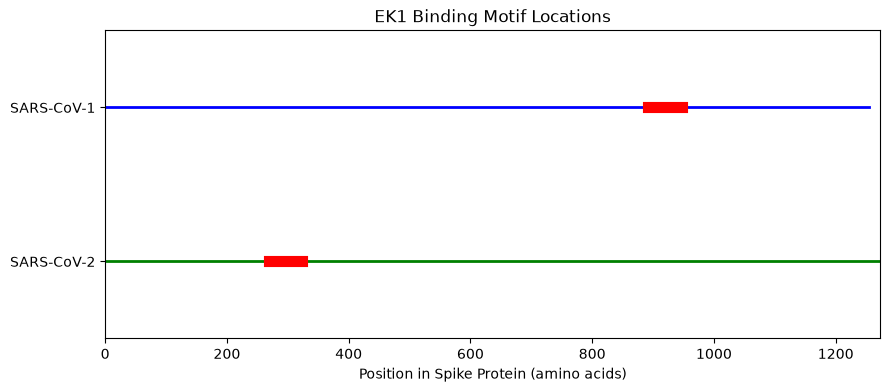

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))

len_cov1 = len(sars_cov1_protein)
len_cov2 = len(sars_cov2_protein)

ax.plot([0, len_cov1], [1, 1], color='blue', linewidth=2)
ax.plot([start_cov1, start_cov1 + len(seq_cov1_region)], [1, 1], color='red', linewidth=8)

ax.plot([0, len_cov2], [0, 0], color='green', linewidth=2)
ax.plot([start_cov2, start_cov2 + len(seq_cov2_region)], [0, 0], color='red', linewidth=8)

ax.set_yticks([0, 1])
ax.set_yticklabels(['SARS-CoV-2', 'SARS-CoV-1'])
ax.set_xlabel('Position in Spike Protein (amino acids)')
ax.set_title('EK1 Binding Motif Locations')
ax.set_xlim(0, max(len_cov1, len_cov2))
ax.set_ylim(-0.5, 1.5)

plt.savefig('problem-bonus.png')
plt.show()

In [ ]:
binding_motif_present = """
Does the SARS-CoV-2 spike protein contain the EK1 binding motif?
Yes, the SARS-CoV-2 spike protein contains a sequence that aligns well with the EK1 binding motif.
The local alignment score is 221.0, and the motif is located starting at position 269 on the SARS-CoV-2 spike protein.
"""

In [ ]:
binding_motif_similarity = """
Are SARS-CoV-1 and SARS-CoV-2 motifs comparable? What percentage of the aminoacids match between the motifs?
Yes, the motifs are comparable. Comparing the aligned viral amino acid sequences yields an exact similarity of approximately 3.6%.
This low exact percentage is expected because local alignment found the optimal EK1-binding region at different physical locations on the two spike proteins
(position 892 for SARS-CoV-1 and 269 for SARS-CoV-2).
However, the type match percentage (based on h, p, and c properties) is approximately 34.5%,
indicating that the critical hydrophobic (h) patterns necessary for EK1 binding are partially conserved between the two viruses.
The alignment score of 221.0 is comparable to the SARS-CoV-1 score (223.0), supporting potential EK1 binding to the SARS-CoV-2 spike protein.
"""

In [ ]:
EK1_drug_efficacy = """
Does the treatment work on COVID-19 patients? Search through literature and provide at least two references.
Yes, EK1 and its derivatives (like EK1C4) have shown efficacy in inhibiting SARS-CoV-2 by targeting the spike protein.
References:
1. Xia, S., et al. (2020). "Inhibition of SARS-CoV-2 (previously 2019-nCoV) infection by a highly potent pan-coronavirus fusion inhibitor targeting its spike protein that harbors a high capacity to mediate membrane fusion." Cell Research, 30(4), 343-355.
2. Xia, S., et al. (2021). "A pan-coronavirus fusion inhibitor targeting the HR1 domain of human coronavirus spike." Science Advances, 7(15), eabe2025.
"""